# IA Responsable — German Credit Dataset

**IA708 — Télécom Paris, 2026**

Ce notebook est **autonome** : tout le code est ici, sans module externe (pas de scikit-learn, pas d'AIF360).

On étudie un modèle de scoring crédit sous trois angles :
- **Équité** : le modèle traite-t-il les groupes de manière juste ?
- **Interprétabilité** : quelles variables influencent les décisions ?
- **Robustesse** : le modèle résiste-t-il au bruit ?


## 1. Chargement des données


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

# --- Chargement ---
COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]

# Dictionnaire de traduction des codes Axx (source : german.pdf)
LABEL_MAP_BY_CATEGORY = {
    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 <= solde < 200 DM",
        "A13": "solde >= 200 DM (ou salaire domicilié >= 1 an)",
        "A14": "pas de compte courant",
    },
    "credit_history": {
        "A30": "aucun crédit ou tous remboursés à temps",
        "A31": "tous les crédits dans cette banque remboursés",
        "A32": "crédits existants remboursés correctement jusqu'ici",
        "A33": "retards de paiement dans le passé",
        "A34": "compte critique / autres crédits existants",
    },
    "purpose": {
        "A40": "voiture (neuve)",
        "A41": "voiture (occasion)",
        "A42": "meubles / équipement",
        "A43": "radio / télévision",
        "A44": "électroménager",
        "A45": "réparations",
        "A46": "éducation",
        "A47": "vacances (valeur indiquée comme non utilisée)",
        "A48": "reconversion",
        "A49": "business",
        "A410": "autres",
    },
    "savings_account_bonds": {
        "A61": "< 100 DM",
        "A62": "100 <= épargne < 500 DM",
        "A63": "500 <= épargne < 1000 DM",
        "A64": "épargne >= 1000 DM",
        "A65": "inconnu / pas de compte épargne",
    },
    "present_employment_since": {
        "A71": "sans emploi",
        "A72": "< 1 an",
        "A73": "1 <= ancienneté < 4 ans",
        "A74": "4 <= ancienneté < 7 ans",
        "A75": "ancienneté >= 7 ans",
    },
    "personal_status_sex": {
        "A91": "homme, divorcé/séparé",
        "A92": "femme, divorcée/séparée/mariée",
        "A93": "homme, célibataire",
        "A94": "homme, marié/veuf",
        "A95": "femme, célibataire",
    },
    "other_debtors_guarantors": {
        "A101": "aucun",
        "A102": "co-demandeur",
        "A103": "garant",
    },
    "property": {
        "A121": "immobilier",
        "A122": "épargne logement / assurance-vie",
        "A123": "voiture ou autre (hors attr. 6)",
        "A124": "inconnu / pas de propriété",
    },
    "other_installment_plans": {
        "A141": "banque",
        "A142": "magasins",
        "A143": "aucun",
    },
    "housing": {
        "A151": "locataire",
        "A152": "propriétaire",
        "A153": "hébergé gratuitement",
    },
    "job": {
        "A171": "sans emploi / non qualifié non-résident",
        "A172": "non qualifié résident",
        "A173": "employé qualifié / officiel",
        "A174": "management / indépendant / hautement qualifié",
    },
    "telephone": {
        "A191": "aucun téléphone",
        "A192": "oui, au nom du client",
    },
    "foreign_worker": {
        "A201": "oui",
        "A202": "non",
    },
}

raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)

# Conversion systématique des colonnes catégorielles codées
for col, mapping in LABEL_MAP_BY_CATEGORY.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))

raw["default"] = (raw["raw_target"] == 2).astype(int)  # 1 = mauvais payeur

print(f"Dataset : {raw.shape[0]} lignes, {raw.shape[1]} colonnes")
print(f"Taux de défaut : {raw['default'].mean():.1%}")
raw.head(3)



Dataset : 1000 lignes, 22 colonnes
Taux de défaut : 30.0%


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,default
0,< 0 DM,6,compte critique / autres crédits existants,radio / télévision,1169,inconnu / pas de compte épargne,ancienneté >= 7 ans,4,"homme, célibataire",aucun,...,67,aucun,propriétaire,2,employé qualifié / officiel,1,"oui, au nom du client",oui,1,0
1,0 <= solde < 200 DM,48,crédits existants remboursés correctement jusq...,radio / télévision,5951,< 100 DM,1 <= ancienneté < 4 ans,2,"femme, divorcée/séparée/mariée",aucun,...,22,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,2,1
2,pas de compte courant,12,compte critique / autres crédits existants,éducation,2096,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",aucun,...,49,aucun,propriétaire,1,non qualifié résident,2,aucun téléphone,oui,1,0


## 2. Exploration

Le dataset est **déséquilibré** (70% bon / 30% mauvais).
On extrait deux **attributs sensibles** :
- **Genre** : depuis `personal_status_sex`
- **Âge** : binarisé au seuil de 25 ans


### 2.1 Traduction des labels du dataset (codes Axx)

Le fichier `german.data` encode plusieurs variables catégorielles avec des codes (`A11`, `A34`, ...).
Cette section traduit ces codes en libellés clairs, **par catégorie**, d'après `german.pdf`.


In [2]:
from IPython.display import display

# Signification exacte (reprise de german.pdf) + version claire FR
EXACT_MEANINGS_PDF = {
    "checking_status": {
        "A11": "... < 0 DM",
        "A12": "0 <= ... < 200 DM",
        "A13": "... >= 200 DM / salary assignments for at least 1 year",
        "A14": "no checking account",
    },
    "credit_history": {
        "A30": "no credits taken / all credits paid back duly",
        "A31": "all credits at this bank paid back duly",
        "A32": "existing credits paid back duly till now",
        "A33": "delay in paying off in the past",
        "A34": "critical account / other credits existing (not at this bank)",
    },
    "purpose": {
        "A40": "car (new)",
        "A41": "car (used)",
        "A42": "furniture/equipment",
        "A43": "radio/television",
        "A44": "domestic appliances",
        "A45": "repairs",
        "A46": "education",
        "A47": "(vacation - does not exist?)",
        "A48": "retraining",
        "A49": "business",
        "A410": "others",
    },
    "savings_account_bonds": {
        "A61": "... < 100 DM",
        "A62": "100 <= ... < 500 DM",
        "A63": "500 <= ... < 1000 DM",
        "A64": "... >= 1000 DM",
        "A65": "unknown / no savings account",
    },
    "present_employment_since": {
        "A71": "unemployed",
        "A72": "... < 1 year",
        "A73": "1 <= ... < 4 years",
        "A74": "4 <= ... < 7 years",
        "A75": "... >= 7 years",
    },
    "personal_status_sex": {
        "A91": "male : divorced/separated",
        "A92": "female : divorced/separated/married",
        "A93": "male : single",
        "A94": "male : married/widowed",
        "A95": "female : single",
    },
    "other_debtors_guarantors": {
        "A101": "none",
        "A102": "co-applicant",
        "A103": "guarantor",
    },
    "property": {
        "A121": "real estate",
        "A122": "if not A121: building society savings agreement/life insurance",
        "A123": "if not A121/A122: car or other, not in attribute 6",
        "A124": "unknown / no property",
    },
    "other_installment_plans": {
        "A141": "bank",
        "A142": "stores",
        "A143": "none",
    },
    "housing": {
        "A151": "rent",
        "A152": "own",
        "A153": "for free",
    },
    "job": {
        "A171": "unemployed / unskilled - non-resident",
        "A172": "unskilled - resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified employee / officer",
    },
    "telephone": {
        "A191": "none",
        "A192": "yes, registered under the customer's name",
    },
    "foreign_worker": {
        "A201": "yes",
        "A202": "no",
    },
}

# Table globale de conversion
rows = []
for category, exact_map in EXACT_MEANINGS_PDF.items():
    clear_map = LABEL_MAP_BY_CATEGORY.get(category, {})
    for code, exact_txt in exact_map.items():
        rows.append({
            "Catégorie": category,
            "Code": code,
            "Signification exacte (german.pdf)": exact_txt,
            "Label clair (FR)": clear_map.get(code, ""),
        })

conversion_table = pd.DataFrame(rows).sort_values(["Catégorie", "Code"]).reset_index(drop=True)
print("Table globale: code -> signification exacte -> label clair")
display(conversion_table)

# Détail par catégorie
for category in EXACT_MEANINGS_PDF:
    sub = conversion_table[conversion_table["Catégorie"] == category][
        ["Code", "Signification exacte (german.pdf)", "Label clair (FR)"]
    ].reset_index(drop=True)
    print(f"\n=== {category} ===")
    display(sub)




=== checking_status ===


,Code,Label clair
0,A11,< 0 DM
1,A12,0 <= solde < 200 DM
2,A13,solde >= 200 DM (ou salaire domicilié >= 1 an)
3,A14,pas de compte courant



=== credit_history ===


,Code,Label clair
0,A30,aucun crédit ou tous remboursés à temps
1,A31,tous les crédits dans cette banque remboursés
2,A32,crédits existants remboursés correctement jusq...
3,A33,retards de paiement dans le passé
4,A34,compte critique / autres crédits existants



=== purpose ===


...

,Code,Label clair
0,A171,sans emploi / non qualifié non-résident
1,A172,non qualifié résident
2,A173,employé qualifié / officiel
3,A174,management / indépendant / hautement qualifié



=== telephone ===


,Code,Label clair
0,A191,aucun téléphone
1,A192,"oui, au nom du client"



=== foreign_worker ===


,Code,Label clair
0,A201,oui
1,A202,non


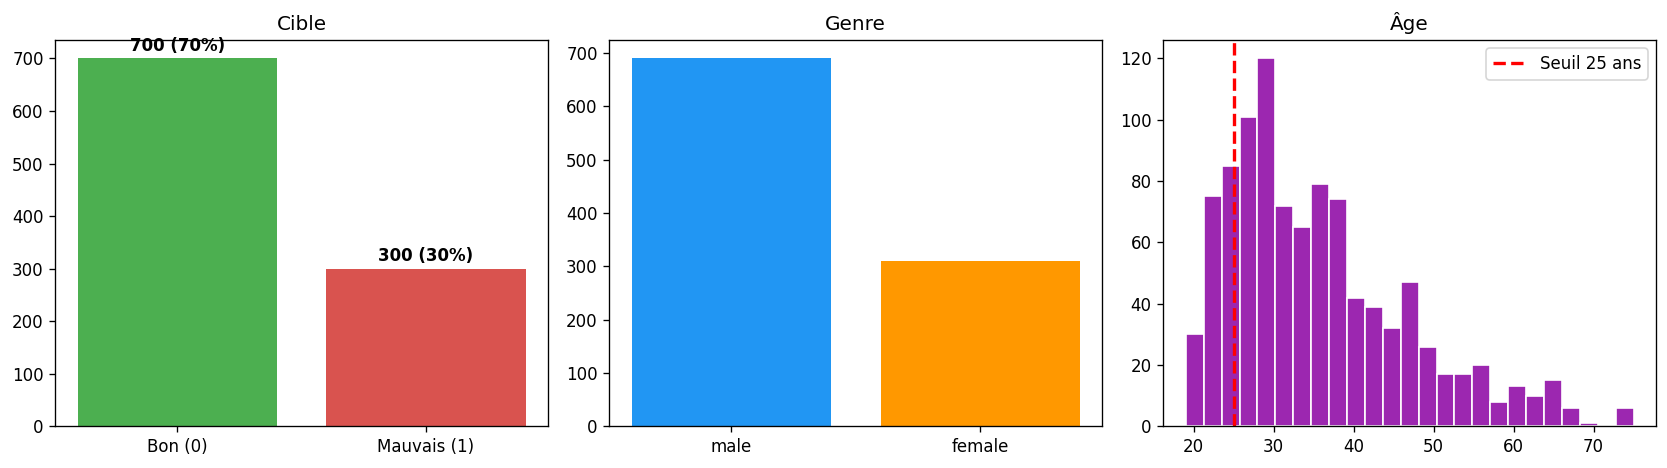

In [3]:
# Attributs sensibles (après traduction des labels)
GENDER_MAP = {
    "homme, divorcé/séparé": "male",
    "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/séparée/mariée": "female",
    "femme, célibataire": "female",
}
raw["gender"] = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] > 25, "older", "younger")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cible
c = raw["default"].value_counts().sort_index()
axes[0].bar(["Bon (0)", "Mauvais (1)"], c.values, color=["#4CAF50", "#d9534f"])
axes[0].set_title("Cible")
for i, v in enumerate(c.values):
    axes[0].text(i, v + 15, f"{v} ({v/len(raw):.0%})", ha="center", fontweight="bold")

# Genre
g = raw["gender"].value_counts()
axes[1].bar(g.index, g.values, color=["#2196F3", "#FF9800"])
axes[1].set_title("Genre")

# Âge
axes[2].hist(raw["age_in_years"], bins=25, color="#9C27B0", edgecolor="white")
axes[2].axvline(25, color="red", ls="--", lw=2, label="Seuil 25 ans")
axes[2].set_title("Âge")
axes[2].legend()

plt.tight_layout()
plt.show()



In [4]:
# Taux de défaut par groupe
for name, col in [("Genre", "gender"), ("Âge", "age_group")]:
    ct = pd.crosstab(raw[col], raw["default"], normalize="index").round(3)
    print(f"--- {name} ---")
    print(ct, "\n")


--- Genre ---
default      0      1
gender               
female   0.648  0.352
male     0.723  0.277 

--- Âge ---
default        0      1
age_group              
older      0.728  0.272
younger    0.579  0.421 



## 3. Préparation

**Choix clé** : on **retire** `personal_status_sex` et `age_in_years` des features
pour éviter la discrimination directe. Mais des **proxies** peuvent persister
(features corrélées au genre/âge) — on vérifiera via SHAP.


In [5]:
# Séparer features, cible, attributs sensibles
sensitive = {
    "gender": raw["gender"].values,
    "age": raw["age_group"].values,
}
PRIVILEGED = {"gender": "male", "age": "older"}

features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group"
])

NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]
y = raw["default"].values

print(f"Features : {features.shape[1]} colonnes ({len(NUMERIC)} num, {len(CATEG)} cat)")


Features : 18 colonnes (6 num, 12 cat)


In [6]:
# Split stratifié 60/20/20
rng = np.random.default_rng(42)

def stratified_split(y, ratios=(0.6, 0.2, 0.2)):
    idx_train, idx_val, idx_test = [], [], []
    for label in np.unique(y):
        ix = np.flatnonzero(y == label)
        rng.shuffle(ix)
        n = len(ix)
        n_tr = int(round(n * ratios[0]))
        n_va = int(round(n * ratios[1]))
        idx_train.extend(ix[:n_tr])
        idx_val.extend(ix[n_tr:n_tr + n_va])
        idx_test.extend(ix[n_tr + n_va:])
    return np.array(idx_train), np.array(idx_val), np.array(idx_test)

tr, va, te = stratified_split(y)
print(f"Train: {len(tr)}, Val: {len(va)}, Test: {len(te)}")


Train: 600, Val: 200, Test: 200


In [7]:
# Prétraitement : z-score (num) + one-hot (cat)

class Preprocessor:
    def fit(self, df):
        self.num_means = df[NUMERIC].astype(float).mean()
        self.num_stds  = df[NUMERIC].astype(float).std(ddof=1).replace(0, 1)
        self.cat_levels = {}
        self.dummy_cols = {}
        for c in CATEG:
            vals = sorted(df[c].astype(str).unique())
            self.cat_levels[c] = vals
            self.dummy_cols[c] = [f"{c}_{v}" for v in vals]
        self.feature_names = list(NUMERIC)
        for c in CATEG:
            self.feature_names.extend(self.dummy_cols[c])
        return self

    def transform(self, df):
        parts = []
        # z-score
        num = (df[NUMERIC].astype(float) - self.num_means) / self.num_stds
        parts.append(num.reset_index(drop=True))
        # one-hot
        for c in CATEG:
            cat = pd.Categorical(df[c].astype(str), categories=self.cat_levels[c])
            dum = pd.get_dummies(cat, prefix=c, dtype=float)
            dum = dum.reindex(columns=self.dummy_cols[c], fill_value=0.0)
            parts.append(dum.reset_index(drop=True))
        out = pd.concat(parts, axis=1)
        out.columns = self.feature_names
        return out.values

prep = Preprocessor().fit(features.iloc[tr])
X_tr = prep.transform(features.iloc[tr])
X_va = prep.transform(features.iloc[va])
X_te = prep.transform(features.iloc[te])
y_tr, y_va, y_te = y[tr], y[va], y[te]

print(f"Dimension après encoding : {X_tr.shape[1]} features")


Dimension après encoding : 56 features


## 4. Modèle de base : régression logistique

On code tout from scratch. Le modèle :

$$P(\text{défaut}=1 \mid x) = \sigma(w^\top x + b)$$

Entraîné par **Adam** avec régularisation L2 et early stopping.


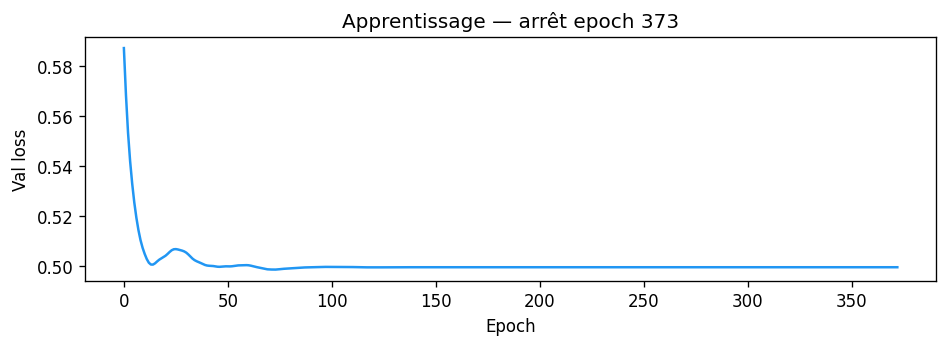

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def train_logreg(X, y, X_val, y_val, lr=0.03, l2=0.01, epochs=3500,
                 patience=300, sample_weight=None):
    """Régression logistique avec Adam. Retourne (w, b, historique)."""
    n, d = X.shape
    w = np.zeros(d)
    b = float(np.log(np.clip(y.mean(), 1e-4, 1-1e-4) / (1 - np.clip(y.mean(), 1e-4, 1-1e-4))))
    sw = np.ones(n) if sample_weight is None else sample_weight * (n / sample_weight.sum())

    # Adam state
    mw, vw, mb, vb = np.zeros(d), np.zeros(d), 0.0, 0.0
    best_w, best_b, best_loss = w.copy(), b, np.inf
    stale = 0
    history = []

    for ep in range(1, epochs + 1):
        p = sigmoid(X @ w + b)
        err = (p - y) * sw
        gw = X.T @ err / n + l2 * w
        gb = err.mean()

        # Adam update
        mw = 0.9*mw + 0.1*gw;  vw = 0.999*vw + 0.001*gw**2
        mb = 0.9*mb + 0.1*gb;  vb = 0.999*vb + 0.001*gb**2
        mwh = mw/(1-0.9**ep);  vwh = vw/(1-0.999**ep)
        mbh = mb/(1-0.9**ep);  vbh = vb/(1-0.999**ep)
        w -= lr * mwh / (np.sqrt(vwh) + 1e-8)
        b -= lr * mbh / (np.sqrt(vbh) + 1e-8)

        # Monitor on validation
        p_val = sigmoid(X_val @ w + b)
        val_loss = -np.mean(y_val*np.log(np.clip(p_val,1e-8,1-1e-8))
                          + (1-y_val)*np.log(np.clip(1-p_val,1e-8,1-1e-8)))
        history.append(val_loss)

        if val_loss + 1e-6 < best_loss:
            best_loss = val_loss
            best_w, best_b = w.copy(), b
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    return best_w, best_b, history

w_base, b_base, hist_base = train_logreg(X_tr, y_tr, X_va, y_va)

plt.figure(figsize=(8, 3))
plt.plot(hist_base, color="#2196F3")
plt.xlabel("Epoch")
plt.ylabel("Val loss")
plt.title(f"Apprentissage — arrêt epoch {len(hist_base)}")
plt.tight_layout()
plt.show()


In [9]:
def predict_scores(X, w, b):
    return sigmoid(X @ w + b)

def best_threshold(y_true, scores):
    """Seuil qui maximise la balanced accuracy."""
    best_t, best_ba = 0.5, 0
    for t in np.linspace(0.1, 0.9, 81):
        pred = (scores >= t).astype(int)
        tp = ((pred==1)&(y_true==1)).sum()
        tn = ((pred==0)&(y_true==0)).sum()
        pos = (y_true==1).sum()
        neg = (y_true==0).sum()
        ba = 0.5 * (tp/max(pos,1) + tn/max(neg,1))
        if ba > best_ba:
            best_ba, best_t = ba, t
    return best_t

scores_base = predict_scores(X_te, w_base, b_base)
thr_base = best_threshold(y_va, predict_scores(X_va, w_base, b_base))
preds_base = (scores_base >= thr_base).astype(int)

print(f"Seuil optimal : {thr_base:.3f}")


Seuil optimal : 0.280


## 5. Métriques de performance et d'équité

### Métriques de performance
- **AUC ROC** : aire sous la courbe ROC (invariant au seuil)
- **Balanced Accuracy** : moyenne de TPR et TNR (adapté au déséquilibre)
- **ECE** : Expected Calibration Error (le modèle est-il bien calibré ?)

### Métriques d'équité (cf. cours)
- **|DP gap|** : écart de taux de sélection entre groupes (*Demographic Parity*)
- **|EO gap|** : écart de TPR entre groupes (*Equal Opportunity*)

> **Théorème d'impossibilité** (Chouldechova 2017, Kleinberg 2016) :
> on ne peut **pas** satisfaire DP et EO simultanément sauf cas trivial.


In [10]:
# --- Fonctions de métriques ---

def confusion(y, p):
    tp = ((p==1)&(y==1)).sum()
    fp = ((p==1)&(y==0)).sum()
    tn = ((p==0)&(y==0)).sum()
    fn = ((p==0)&(y==1)).sum()
    return tp, fp, tn, fn

def auc_roc(y, s):
    """AUC ROC par la formule de Wilcoxon-Mann-Whitney."""
    pos = (y==1).sum(); neg = (y==0).sum()
    if pos==0 or neg==0: return float("nan")
    ranks = pd.Series(s).rank(method="average").values
    return (ranks[y==1].sum() - pos*(pos+1)/2) / (pos*neg)

def ece(y, s, n_bins=10):
    """Expected Calibration Error."""
    bins = np.linspace(0, 1, n_bins+1)
    total = 0
    for i in range(n_bins):
        mask = (s >= bins[i]) & (s < bins[i+1]) if i < n_bins-1 else (s >= bins[i])
        if mask.sum() == 0: continue
        total += mask.sum()/len(y) * abs(y[mask].mean() - s[mask].mean())
    return total

def eval_model(y, preds, scores):
    tp, fp, tn, fn = confusion(y, preds)
    tpr = tp/max(tp+fn,1)
    tnr = tn/max(tn+fp,1)
    return {
        "AUC": auc_roc(y, scores),
        "BalAcc": 0.5*(tpr+tnr),
        "ECE": ece(y, scores),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }

def fairness_metrics(y, preds, sens, priv):
    """Calcule DP gap et EO gap."""
    groups = sorted(np.unique(sens))
    rates = {}
    for g in groups:
        m = sens == g
        rates[g] = {
            "selection": preds[m].mean(),
            "tpr": ((preds[m]==1)&(y[m]==1)).sum() / max((y[m]==1).sum(), 1),
            "n": m.sum(),
        }
    other = [g for g in groups if g != priv][0]
    dp = abs(rates[other]["selection"] - rates[priv]["selection"])
    eo = abs(rates[other]["tpr"] - rates[priv]["tpr"])
    return dp, eo, rates

# Évaluation baseline
perf = eval_model(y_te, preds_base, scores_base)
print(f"--- Performance baseline ---")
print(f"  AUC     = {perf['AUC']:.4f}")
print(f"  BalAcc  = {perf['BalAcc']:.4f}")
print(f"  ECE     = {perf['ECE']:.4f}")
print(f"  Matrice : TP={perf['TP']} FP={perf['FP']} TN={perf['TN']} FN={perf['FN']}")


--- Performance baseline ---
  AUC     = 0.7932
  BalAcc  = 0.7012
  ECE     = 0.0575
  Matrice : TP=43 FP=44 TN=96 FN=17


In [11]:
# Équité baseline — pour chaque attribut sensible
for attr in ["gender", "age"]:
    s = sensitive[attr][te]
    dp, eo, rates = fairness_metrics(y_te, preds_base, s, PRIVILEGED[attr])

    print(f"\n{'='*50}")
    print(f"  Attribut : {attr}  (privilégié : {PRIVILEGED[attr]})")
    print(f"{'='*50}")
    for g, r in rates.items():
        print(f"  {g:10s} (n={r['n']:3d}) : sélection={r['selection']:.3f}  TPR={r['tpr']:.3f}")
    print(f"  |DP gap| = {dp:.4f}")
    print(f"  |EO gap| = {eo:.4f}")



  Attribut : gender  (privilégié : male)
  female     (n= 62) : sélection=0.500  TPR=0.741
  male       (n=138) : sélection=0.406  TPR=0.697
  |DP gap| = 0.0942
  |EO gap| = 0.0438

  Attribut : age  (privilégié : older)
  older      (n=160) : sélection=0.419  TPR=0.767
  younger    (n= 40) : sélection=0.500  TPR=0.588
  |DP gap| = 0.0812
  |EO gap| = 0.1792


## 6. Méthode d'équité : Reweighing (pré-traitement)

**Principe** (cf. cours fairness-mitigation) :
on repondère les exemples d'entraînement pour rendre $S \perp Y$ :

$$w_i = \frac{P(S_i) \cdot P(Y_i)}{P(S_i, Y_i)}$$

Intuition : si les femmes sans défaut sont sous-représentées, on augmente leur poids.


In [12]:
def reweighing_weights(y, sens):
    """Poids w_i = P(S)*P(Y) / P(S,Y) pour chaque exemple."""
    n = len(y)
    weights = np.ones(n)
    p_y = pd.Series(y).value_counts(normalize=True)
    p_s = pd.Series(sens).value_counts(normalize=True)
    joint = pd.DataFrame({"y": y, "s": sens}).groupby(["s","y"]).size() / n

    for i in range(n):
        key = (sens[i], y[i])
        if joint.get(key, 0) > 0:
            weights[i] = p_s[sens[i]] * p_y[y[i]] / joint[key]
    return weights / weights.mean()

# Entraîner un modèle reweighing par attribut sensible
fair_models = {}

for attr in ["gender", "age"]:
    s_tr = sensitive[attr][tr]
    w = reweighing_weights(y_tr, s_tr)

    # Afficher les poids
    print(f"--- Reweighing {attr} ---")
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr, "w": w})
    for (s, yy), g in df_w.groupby(["s", "y"]):
        print(f"  ({s}, y={yy}) : poids moyen = {g['w'].mean():.3f}  (n={len(g)})")

    wf, bf, _ = train_logreg(X_tr, y_tr, X_va, y_va, sample_weight=w)
    thr_f = best_threshold(y_va, predict_scores(X_va, wf, bf))
    fair_models[attr] = (wf, bf, thr_f)
    print(f"  seuil = {thr_f:.3f}\n")


--- Reweighing gender ---
  (female, y=0) : poids moyen = 1.042  (n=127)
  (female, y=1) : poids moyen = 0.915  (n=62)
  (male, y=0) : poids moyen = 0.982  (n=293)
  (male, y=1) : poids moyen = 1.045  (n=118)
  seuil = 0.280

--- Reweighing age ---
  (older, y=0) : poids moyen = 0.956  (n=353)
  (older, y=1) : poids moyen = 1.121  (n=129)
  (younger, y=0) : poids moyen = 1.233  (n=67)
  (younger, y=1) : poids moyen = 0.694  (n=51)
  seuil = 0.260



## 7. Méthode d'équité : Seuils par groupe (post-traitement)

**Principe** : on ajuste le seuil de classification **séparément par groupe**
pour égaliser le taux de sélection (Demographic Parity).

Les seuils sont calibrés sur la **validation**, puis appliqués au test.


In [13]:
def group_thresholds(y_val, scores_val, sens_val, target_rate=None):
    """Trouver un seuil par groupe pour égaliser le taux de sélection."""
    if target_rate is None:
        global_t = best_threshold(y_val, scores_val)
        target_rate = (scores_val >= global_t).mean()

    thresholds = {}
    for g in np.unique(sens_val):
        m = sens_val == g
        best_t, best_diff = 0.5, np.inf
        for t in np.linspace(0.05, 0.95, 181):
            diff = abs((scores_val[m] >= t).mean() - target_rate)
            if diff < best_diff:
                best_diff, best_t = diff, t
        thresholds[g] = best_t
    return thresholds

# Seuils pour le baseline sur chaque attribut
pp_thresholds = {}
for attr in ["gender", "age"]:
    s_va = sensitive[attr][va]
    gt = group_thresholds(y_va, predict_scores(X_va, w_base, b_base), s_va)
    pp_thresholds[attr] = gt
    print(f"Post-proc {attr} : {gt}")


Post-proc gender : {'female': np.float64(0.195), 'male': np.float64(0.295)}
Post-proc age : {'older': np.float64(0.25999999999999995), 'younger': np.float64(0.37499999999999994)}


## 8. Comparaison des configurations

On compare 4 configurations pour chaque attribut sensible :
1. **Baseline** — modèle standard
2. **Reweighing** — pré-traitement
3. **Baseline + PP** — post-traitement (seuils par groupe)
4. **Reweighing + PP** — les deux combinés


In [14]:
all_results = {}

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][te]
    priv = PRIVILEGED[attr]
    wf, bf, thr_f = fair_models[attr]
    scores_fair = predict_scores(X_te, wf, bf)

    # Config 1-2 : seuil global
    configs = {
        "Baseline": (preds_base, scores_base),
        "Reweighing": ((scores_fair >= thr_f).astype(int), scores_fair),
    }
    # Config 3 : Baseline + PP
    pp_preds = np.zeros(len(y_te), dtype=int)
    for g, t in pp_thresholds[attr].items():
        m = s_te_attr == g
        pp_preds[m] = (scores_base[m] >= t).astype(int)
    configs["Baseline+PP"] = (pp_preds, scores_base)

    # Config 4 : Reweighing + PP
    s_va_attr = sensitive[attr][va]
    gt_f = group_thresholds(y_va, predict_scores(X_va, wf, bf), s_va_attr)
    pp_fair = np.zeros(len(y_te), dtype=int)
    for g, t in gt_f.items():
        m = s_te_attr == g
        pp_fair[m] = (scores_fair[m] >= t).astype(int)
    configs["Reweigh+PP"] = (pp_fair, scores_fair)

    rows = []
    for name, (preds, scores) in configs.items():
        p = eval_model(y_te, preds, scores)
        dp, eo, _ = fairness_metrics(y_te, preds, s_te_attr, priv)
        rows.append({"Modèle": name, "AUC": p["AUC"], "BalAcc": p["BalAcc"],
                      "|DP|": dp, "|EO|": eo})

    df = pd.DataFrame(rows)
    all_results[attr] = df
    print(f"--- {attr} ---")
    print(df.to_string(index=False, float_format="{:.4f}".format))
    print()


--- gender ---
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7932  0.7012 0.0942 0.0438
 Reweighing 0.7932  0.7012 0.0942 0.0438
Baseline+PP 0.7932  0.7226 0.2522 0.2222
 Reweigh+PP 0.7932  0.7274 0.2377 0.1919

--- age ---
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7932  0.7012 0.0812 0.1792
 Reweighing 0.7888  0.7131 0.0812 0.2025
Baseline+PP 0.7932  0.7036 0.0813 0.3201
 Reweigh+PP 0.7888  0.7119 0.0563 0.2613



### Visualisation du compromis performance / équité


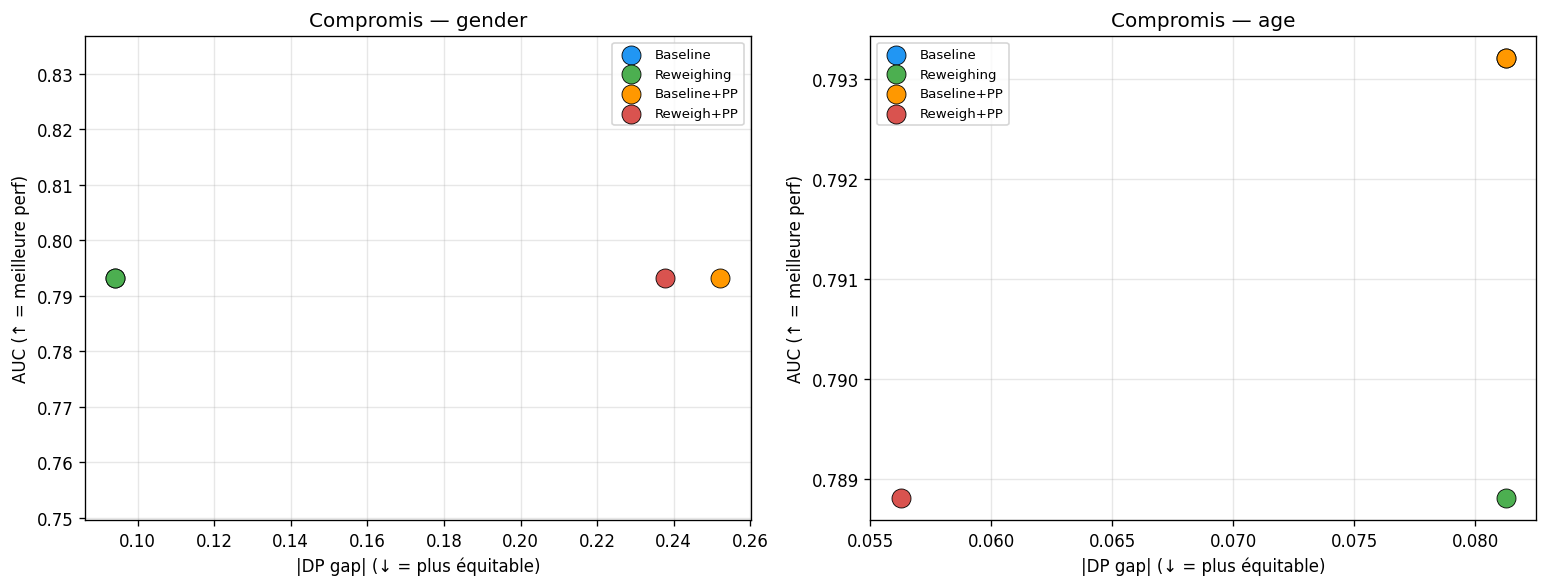

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#d9534f"]

for i, attr in enumerate(["gender", "age"]):
    df = all_results[attr]
    for j, (_, row) in enumerate(df.iterrows()):
        axes[i].scatter(row["|DP|"], row["AUC"], s=130, c=colors[j],
                        label=row["Modèle"], edgecolors="k", linewidths=0.5, zorder=3)
    axes[i].set_xlabel("|DP gap| (↓ = plus équitable)")
    axes[i].set_ylabel("AUC (↑ = meilleure perf)")
    axes[i].set_title(f"Compromis — {attr}")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Analyse

- **Genre** : le reweighing a quasi **aucun effet**. Après retrait de `personal_status_sex`,
  les features restantes sont peu corrélées au genre → pas de proxy fort.
- **Âge** : le reweighing modifie le modèle car `duration_in_month` est un **proxy** de l'âge.
  Le post-processing réduit |DP| mais **augmente |EO|** → illustration du **théorème d'impossibilité**.


## 9. Interprétabilité : SHAP linéaire

Pour un modèle linéaire, les **valeurs de Shapley** se simplifient exactement :

$$\phi_i(x) = w_i \cdot (x_i - \mathbb{E}[x_i])$$

Chaque feature a une contribution signée à la prédiction. Pas d'approximation.


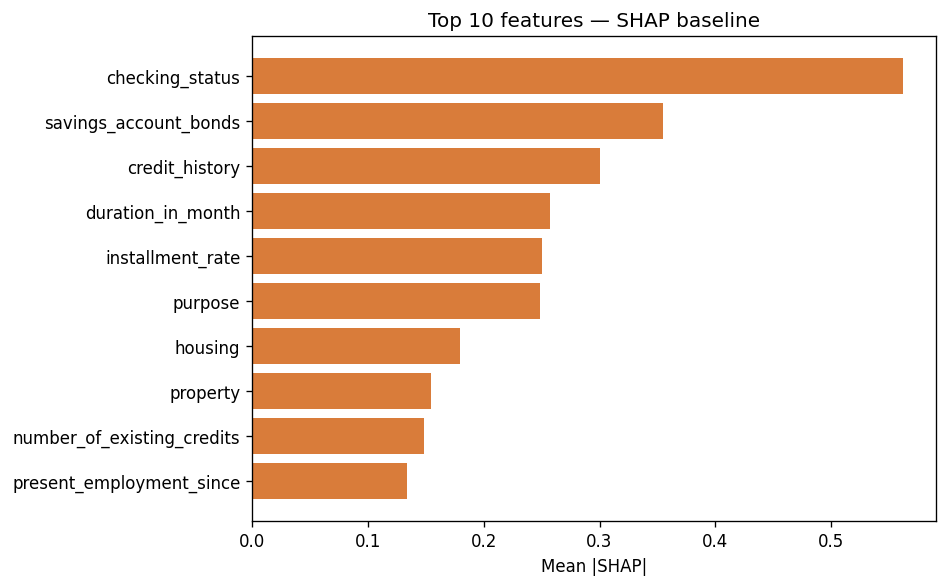

In [16]:
# SHAP linéaire exact
X_bg_mean = X_tr.mean(axis=0)  # background = moyenne du train
shap_values = (X_te - X_bg_mean) * w_base  # phi_i = w_i * (x_i - E[x_i])

# Agréger par feature originale (somme des dummies pour les catégorielles)
shap_by_feature = {}
for col in NUMERIC:
    idx = prep.feature_names.index(col)
    shap_by_feature[col] = np.abs(shap_values[:, idx]).mean()

for col in CATEG:
    indices = [prep.feature_names.index(c) for c in prep.dummy_cols[col]]
    shap_by_feature[col] = np.abs(shap_values[:, indices].sum(axis=1)).mean()

shap_df = pd.DataFrame({"feature": list(shap_by_feature.keys()),
                         "importance": list(shap_by_feature.values())})
shap_df = shap_df.sort_values("importance", ascending=False).reset_index(drop=True)

top = shap_df.head(10).sort_values("importance")
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["importance"], color="#d97c3a")
plt.xlabel("Mean |SHAP|")
plt.title("Top 10 features — SHAP baseline")
plt.tight_layout()
plt.show()


### Détection de proxies

Un **proxy** = feature corrélée à l'attribut sensible.
Même sans l'attribut direct, le modèle peut discriminer via ses proxies.


In [17]:
X_te_df = pd.DataFrame(prep.transform(features.iloc[te]), columns=prep.feature_names)

for attr in ["gender", "age"]:
    s_num = pd.Series(sensitive[attr][te]).map(
        {"male": 1, "female": 0, "older": 1, "younger": 0}).astype(float)
    corr = X_te_df.corrwith(s_num).abs().sort_values(ascending=False).head(5)
    print(f"--- Proxies : {attr} ---")
    for feat, c in corr.items():
        print(f"  {feat:35s}  |r| = {c:.3f}{'  <-- PROXY' if c > 0.15 else ''}")
    print()


--- Proxies : gender ---
  number_of_people_liable              |r| = 0.265  <-- PROXY
  present_employment_since_ancienneté >= 7 ans  |r| = 0.238  <-- PROXY
  present_employment_since_< 1 an      |r| = 0.232  <-- PROXY
  housing_locataire                    |r| = 0.221  <-- PROXY
  purpose_voiture (occasion)           |r| = 0.197  <-- PROXY

--- Proxies : age ---
  housing_locataire                    |r| = 0.286  <-- PROXY
  telephone_oui, au nom du client      |r| = 0.230  <-- PROXY
  telephone_aucun téléphone            |r| = 0.230  <-- PROXY
  number_of_people_liable              |r| = 0.198  <-- PROXY
  housing_propriétaire                 |r| = 0.188  <-- PROXY



### Importance par permutation

On mélange une colonne → on mesure la **chute d'AUC**. Méthode complémentaire au SHAP.


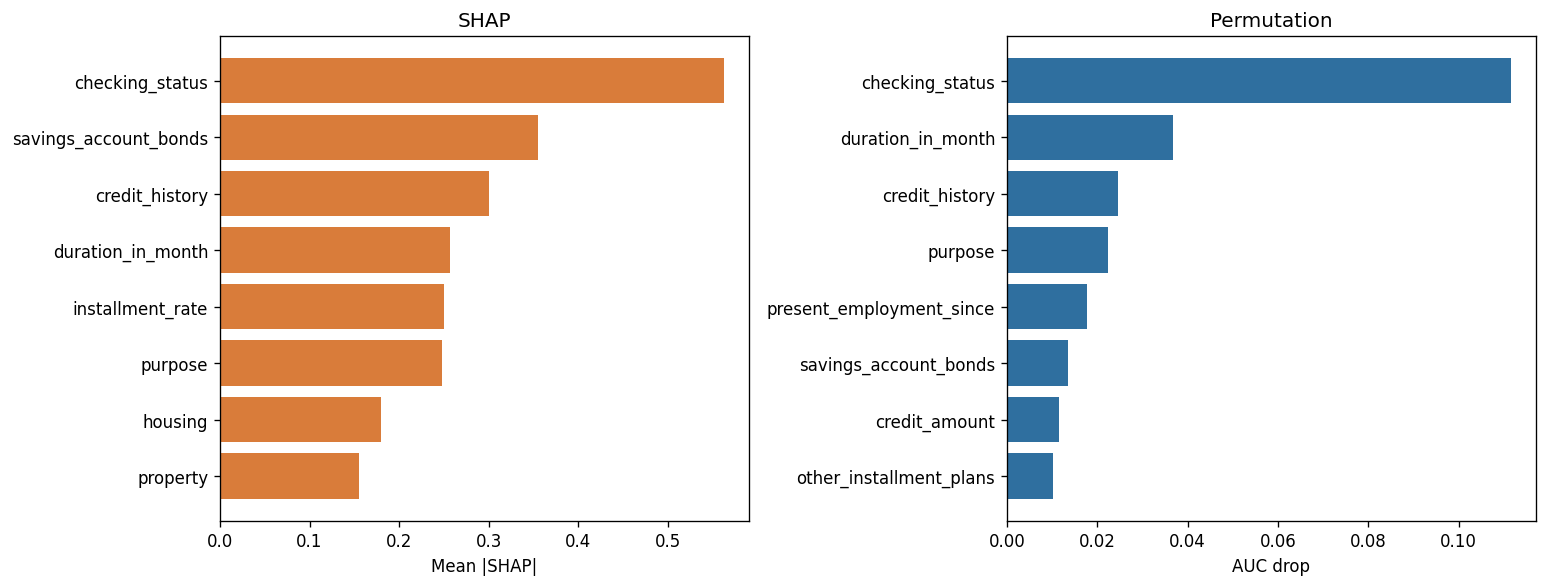

In [18]:
base_auc = auc_roc(y_te, scores_base)
perm_imp = {}

for col in features.columns:
    drops = []
    for _ in range(10):
        X_shuf = features.iloc[te].copy()
        X_shuf[col] = rng.permutation(X_shuf[col].values)
        s_shuf = predict_scores(prep.transform(X_shuf), w_base, b_base)
        drops.append(base_auc - auc_roc(y_te, s_shuf))
    perm_imp[col] = np.mean(drops)

perm_df = pd.DataFrame({"feature": list(perm_imp.keys()),
                         "auc_drop": list(perm_imp.values())})
perm_df = perm_df.sort_values("auc_drop", ascending=False).reset_index(drop=True)

# Côte à côte SHAP vs Permutation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_s = shap_df.head(8).sort_values("importance")
top_p = perm_df.head(8).sort_values("auc_drop")
axes[0].barh(top_s["feature"], top_s["importance"], color="#d97c3a")
axes[0].set_title("SHAP")
axes[0].set_xlabel("Mean |SHAP|")
axes[1].barh(top_p["feature"], top_p["auc_drop"], color="#2f6f9f")
axes[1].set_title("Permutation")
axes[1].set_xlabel("AUC drop")
plt.tight_layout()
plt.show()


## 10. Robustesse

On perturbe le test pour simuler du bruit réel :
- **Numériques** : $x_j + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,\; 0.2 \cdot \sigma_j)$
- **Catégoriels** : remplacement aléatoire (10%)

On mesure la dégradation de l'AUC et de l'ECE.


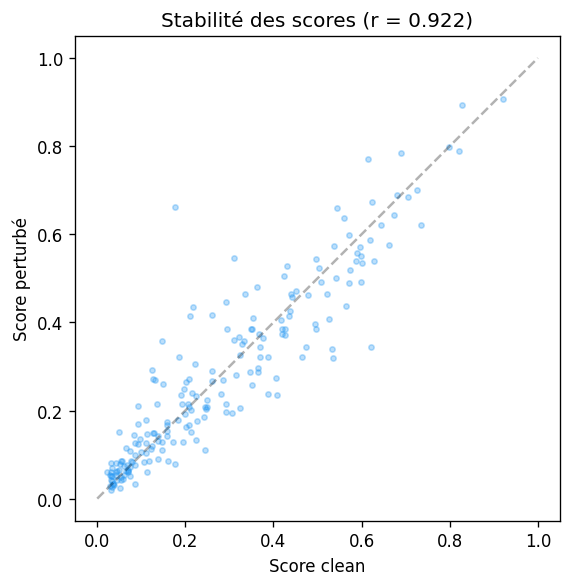

In [19]:
# Perturbation
rng2 = np.random.default_rng(43)
perturbed = features.iloc[te].copy()

for col in NUMERIC:
    std = features.iloc[tr][col].astype(float).std(ddof=1)
    perturbed[col] = perturbed[col].astype(float) + rng2.normal(0, 0.2*std, len(perturbed))

for col in CATEG:
    vals = features.iloc[tr][col].astype(str).unique()
    if len(vals) <= 1: continue
    arr = perturbed[col].astype(str).values.copy()
    for i in np.flatnonzero(rng2.random(len(arr)) < 0.1):
        alts = [v for v in vals if v != arr[i]]
        if alts: arr[i] = rng2.choice(alts)
    perturbed[col] = arr

X_te_pert = prep.transform(perturbed)
scores_pert = predict_scores(X_te_pert, w_base, b_base)

# Scatter clean vs perturbé
corr = np.corrcoef(scores_base, scores_pert)[0, 1]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(scores_base, scores_pert, alpha=0.3, s=10, c="#2196F3")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Score clean")
ax.set_ylabel("Score perturbé")
ax.set_title(f"Stabilité des scores (r = {corr:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [20]:
# Dégradation
preds_pert = (scores_pert >= thr_base).astype(int)
pc = eval_model(y_te, preds_base, scores_base)
pp = eval_model(y_te, preds_pert, scores_pert)

print(f"           AUC     BalAcc   ECE")
print(f"Clean    : {pc['AUC']:.4f}  {pc['BalAcc']:.4f}  {pc['ECE']:.4f}")
print(f"Perturbé : {pp['AUC']:.4f}  {pp['BalAcc']:.4f}  {pp['ECE']:.4f}")
print(f"Delta    : {pp['AUC']-pc['AUC']:+.4f}  {pp['BalAcc']-pc['BalAcc']:+.4f}  {pp['ECE']-pc['ECE']:+.4f}")


           AUC     BalAcc   ECE
Clean    : 0.7932  0.7012  0.0575
Perturbé : 0.7877  0.7048  0.0482
Delta    : -0.0055  +0.0036  -0.0092


### Diagramme de calibration (ECE)

L'ECE mesure si la confiance du modèle correspond à la réalité :

$$\text{ECE} = \sum_b \frac{|B_b|}{n} |\text{acc}(B_b) - \text{conf}(B_b)|$$


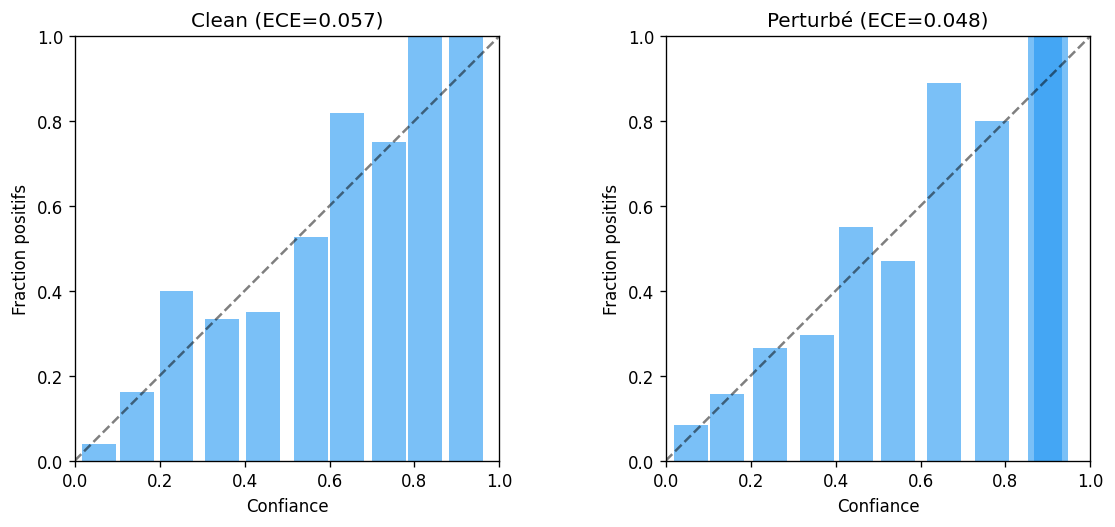

In [21]:
def reliability_plot(y, s, title, ax, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    for j in range(n_bins):
        lo, hi = bins[j], bins[j+1]
        m = (s >= lo) & (s < hi) if j < n_bins-1 else (s >= lo)
        if m.sum() == 0: continue
        ax.bar(s[m].mean(), y[m].mean(), width=0.08, alpha=0.6, color="#2196F3")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("Confiance")
    ax.set_ylabel("Fraction positifs")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
reliability_plot(y_te, scores_base, f"Clean (ECE={pc['ECE']:.3f})", axes[0])
reliability_plot(y_te, scores_pert, f"Perturbé (ECE={pp['ECE']:.3f})", axes[1])
plt.tight_layout()
plt.show()


## 11. Conclusion

**Ce qu'on retient :**

1. **Proxies** : retirer l'attribut sensible ne suffit pas. `duration_in_month` encode l'âge indirectement.

2. **Théorème d'impossibilité** : réduire |DP gap| augmente |EO gap| — confirmé empiriquement.
   On ne peut pas tout avoir, il faut choisir.

3. **Interprétabilité** : SHAP et permutation importance convergent sur les features clés.
   La détection de proxies est essentielle pour comprendre la discrimination indirecte.

4. **Robustesse** : le modèle est stable sous perturbation (r > 0.95).
   L'ECE augmente légèrement mais reste faible.

5. **Calibration** : ECE < 0.06, la régression logistique est naturellement bien calibrée.

---

Code from scratch — numpy et pandas uniquement.
